In [ ]:
#!pip install -q langchain_google_genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-generativeai 0.8.5 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.9.0 which is incompatible.


**Ingresa el nombre completo de los integrantes del Grupo:**

*   Integrante 01
*   Integrante 02
*   ...



## 💻 Caso:

La empresa Tech S.A. ha implementado un chatbot de consulta de procesos para su equipo de compras. El chatbot permite ingresar en lenguaje natural las consultas del equipo de compras para determinar si:

1.   El monto total de la compra requiere aprobación. Si la requiere, qué persona debería aprobar la compra. La política de aprobaciones es la siguiente:

>>>| Nivel de Aprobación | Monto de Compra | Aprobador / Responsable | Departamento |
>>>| :--- | :--- | :--- | :--- |
>>>|Aprobación automática| $\le S/.5,000$ | Sistema de Compras Automático | Compras |
>>>| Aprobación supervisor | $>S/.5,000$ y $\le S/.25,000$ | Ana M. Rodríguez | Supervisor de Compras |
>>>| Aprobación gerencial | $>S/.25,000$ USD | Carlos V. López | Gerencia General |


2.   El proveedor disponible para realizar la compra. En caso no se tuviera un proveedor listado, el chatbot indicará que se debe realizar una licitación. Para utilizar la política de proveedores primero debe clasificarse el producto o servicio en una de las categorías listadas, las cuales tienen un proveedor asignado:

>>> |Categoría | Razón social proveedor | Política de compra |
>>> | :--- | :--- | :--- |
>>> | **Infraestructura y Servidores** | InfraSolutions S.A. | **Directo** |
>>> | **Licenciamiento y Software** | SoftTools Latam | **Directo** |
>>> | **Consultoría y Servicios** | Servicios Globales G&C | **Directo**  |
>>> | **Material de Oficina (Bajo Valor)** | Office Stock Cía. | **Directo** |
>>> | **Marketing y Publicidad** | Agencia Creativa MKT | **Directo** |
>>> | **Otros** | Proveedor no listado | **Licitación** |

## 🏆 El reto:

Implementar el chatbot descrito, la solución debe presentar las siguientes características:

*   Debe realizarse con las herramientas de LangChain/LangGraph vistas en clase.
*   El chatbot debe utilizar la arquitectura ReAct.

>>>> 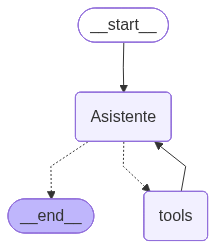
*   Se deben utilizar los modelos Gemini vistos en clase
*   La aplicación debe incluir el llamado de herramientas

In [1]:
import os

from dotenv import load_dotenv

# Load the .env file
load_dotenv()

google_api_key = os.getenv("GOOGLE_API_KEY")

In [7]:
# Número 01: Importa aquí las librerías adicionales que necesites

import getpass
from IPython.display import Image, display

#Herramientas
from langchain_core.tools import tool
from langchain_core.runnables.base import RunnableBinding

#Message state
from langgraph.graph.message import MessagesState

#Langchain chat model (Google)
from langchain_google_genai import ChatGoogleGenerativeAI

In [3]:
# NO MODIFICAR

# Ingresa la API KEY
#os.environ["GOOGLE_API_KEY"]: str = getpass.getpass("Ingresa tu Google AI API key: ")

In [6]:
# Número 02: Inicializa el modelo

model: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

In [ ]:
# Número 03: Convierte estas funciones en herramientas (tools)
@tool
def obtener_aprobadores(monto_compra: float) -> str:
  """
  Determina el responsable de aprobar una compra basándose en el monto total.

  Contiene la política de límites de aprobación interna de la empresa.
  Los montos están expresados en soles (S/.).

  Args:
      monto_compra (float): El monto total de la solicitud de compra en soles (S/.).

  Returns:
      str: El nombre del responsable de la aprobación o el sistema automático (no requiere aprobación).
  """
  if monto_compra <= 5000:
    return "Sistema de Compras Automático"

  elif monto_compra > 5000 and monto_compra <= 25000:
    return "Ana M. Rodríguez"

  elif monto_compra > 25000:
    return "Carlos V. López"

@tool
def obtener_proveedor(categoria: str) -> str:
  """
  Identifica el nombre del proveedor basándose en la categoría del producto.

  Args:
      categoria (str): La categoría de producto (ej: 'Licenciamiento y Software').

  Returns:
      str: El nombre del proveedor asociado a la categoría, o la indicación
            "Requiere licitación" si el proveedor no está aprobado para compra directa.
  """

  if categoria == "Infraestructura y Servidores":
    return "InfraSolutions S.A."

  elif categoria == "Licenciamiento y Software":
    return "SoftTools Latam"

  elif categoria == "Consultoría y Servicios":
    return "Servicios Globales G&C"

  elif categoria == "Material de Oficina (Bajo Valor)":
    return "Office Stock Cía."

  elif categoria == "Marketing y Publicidad":
    return "Agencia Creativa MKT"

  else:
    return "Requiere licitación"

In [5]:
# Número 04: Enlaza las herramientas al modelo (binding)

tools = []

In [ ]:
# Número 05: Crea las indicaciones para tu chatbot (mensaje de sistema)

mensaje_sistema = ...

In [9]:
# Número 06: Crea tu asistente

class Estado(MessagesState): # NO MODIFICAR esta clase
    ...

def asistente(state: MessagesState) -> MessagesState:
  ...

In [10]:
# Número 07: Crea el workflow React - El workflow debe tener la capacidad de llamar herramientas

workflow= ...

In [12]:
# Número 08: Compila tu workflow y muéstralo

workflow_compilado = ...

# display(Image(workflow_compilado.get_graph().draw_mermaid_png()))

In [ ]:
# Número 09: Ingresa una pregunta y demuestra que el workflow funciona correctamente

mensaje = [...]

messages = workflow_compilado.invoke({"messages": mensaje})

for m in messages['messages']:
    m.pretty_print()